<a href="https://colab.research.google.com/github/harshit-538/ML-DL/blob/main/7_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CNN:**
  - In this series we already did digit classification which has 28*28 image size of which we have converted it into 784 size single array and that was first layers and then we trained ANN.
  - But What if image size if 1920*1440 = 2.7 million in just 1st layer.
  - So instead of flattening images, in CNN we find features using filters which is called convolution operation
  - Generally 3*3 filter multiply each element with another elements and average it like this:

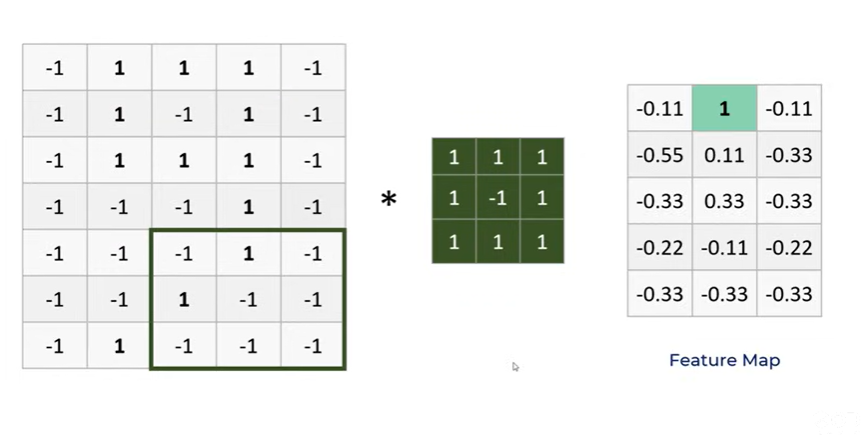

  - stride: how many step filter moves is called stride
  - whenever in feature map value is close to 1 means that feature is present in the image
  - filters are feature detector.
  - This features can be in multiple layers like below and then we flatten final layer so from there we get a dense Neural network.
  - First part is feature extraction and second is classification.

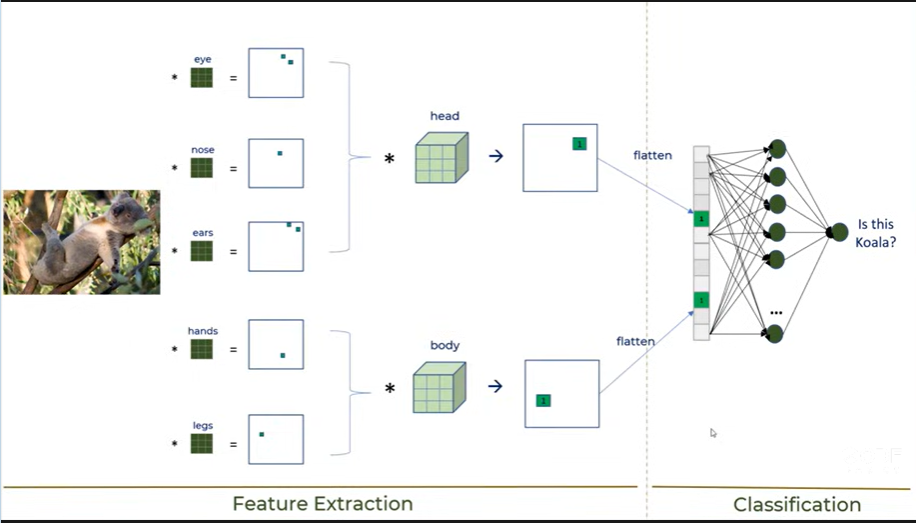

  - in each filter first find feature map and then apply ReLU so that helps with making the model nonlinear.
  - So using this only we didn't solve the main issue of image size.SO WE USE POOLING LAYER TO reduce size.
  - main purpose of pooling layers is to reduce size.
  - Max Pooling,Average Pooling

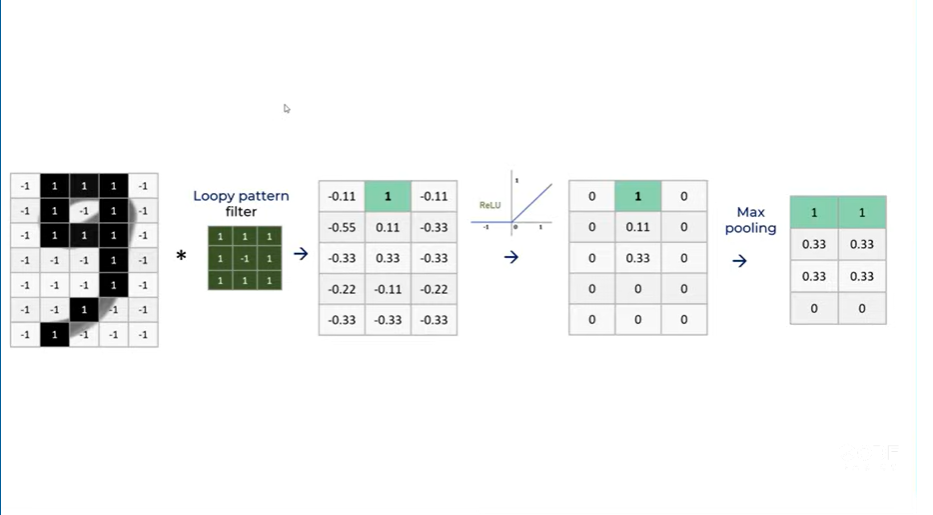

### Benefits of pooling
  - it reduces dimension & computation
  - reduce overfiting as there are less parameters
  - model is toleran towards variations distortions

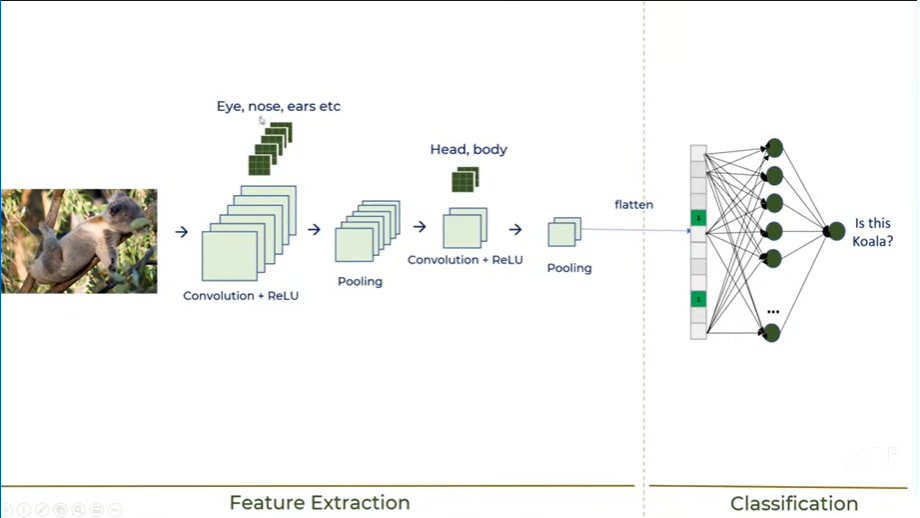

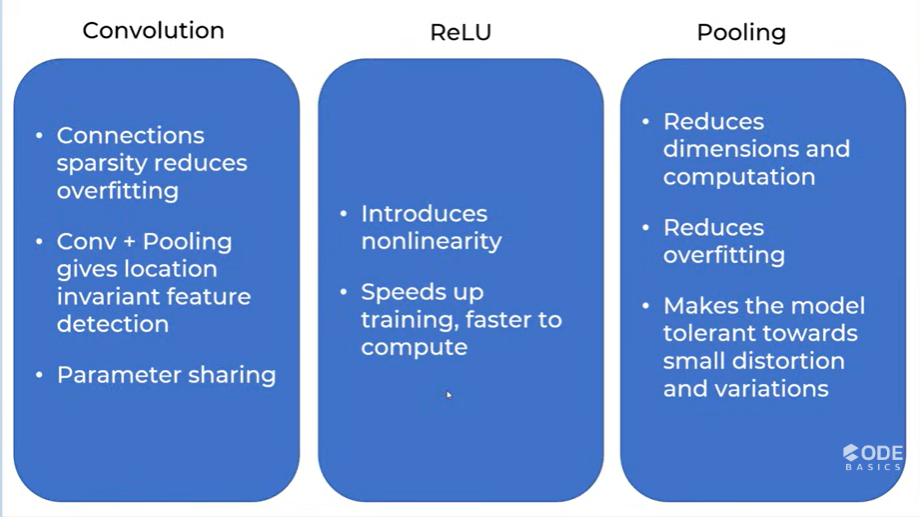

CNN by itself doesn't take care of rotation and scale

 -  you need to have rotated ,scaled samples in training dataset
 - If you don't have such samples than use data augmentation methods to generate new rotated/scaled samples from existing training samples

In [1]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

In [2]:
(X_train,y_train),(X_test,y_test) = keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [3]:
X_train.shape , X_test.shape

((50000, 32, 32, 3), (10000, 32, 32, 3))

In [4]:
y_train.shape

(50000, 1)

In [5]:
y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [6]:
y_train = y_train.reshape(-1,)
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [31]:
classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

In [8]:
def plot_sample(X,y,index):
  plt.figure(figsize = (15,2))
  plt.imshow(X_train[index])
  plt.xlabel(classes[y[index]])

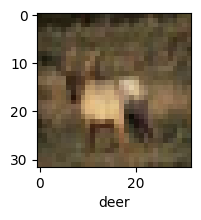

In [9]:
plot_sample(X_train,y_train,3)

In [10]:
X_train = X_train/255
X_test = X_test/255

### First build a simple ANN and then compare it with CNN


In [11]:

ann = keras.Sequential([
    keras.layers.Flatten(input_shape = (32,32,3)),
    keras.layers.Dense(3000,activation='relu'),
    keras.layers.Dense(1000,activation='relu'),
    keras.layers.Dense(10,activation='sigmoid')
])

ann.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
#In this multi class classification if y is one hot encoding value
#then use categorical_crossentroy and if it is a value then use
#sparse_catrgorical_crossentropy

ann.fit(X_train,y_train,epochs=5)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.2690 - loss: 2.2317
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.3930 - loss: 1.6935
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.4232 - loss: 1.6011
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.4517 - loss: 1.5285
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.4656 - loss: 1.4858


In [12]:
ann.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4661 - loss: 1.5141


[1.513815999031067, 0.46459999680519104]

In [13]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
y_pred = ann.predict(X_test)
y_pred_classes = [np.argmax(ele) for ele in y_pred]

print("Classification Report: \n", classification_report(y_test, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Classification Report: 
               precision    recall  f1-score   support

           0       0.49      0.57      0.52      1000
           1       0.64      0.50      0.56      1000
           2       0.36      0.26      0.30      1000
           3       0.34      0.17      0.22      1000
           4       0.44      0.39      0.41      1000
           5       0.38      0.44      0.41      1000
           6       0.37      0.71      0.49      1000
           7       0.64      0.42      0.51      1000
           8       0.53      0.68      0.60      1000
           9       0.54      0.51      0.52      1000

    accuracy                           0.46     10000
   macro avg       0.47      0.46      0.45     10000
weighted avg       0.47      0.46      0.45     10000



### Now Try it with CNN and then dense neural network

In [15]:
cnn = keras.Sequential([
    #CNN Layers
    keras.layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu',input_shape=(32,32,3)),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
    keras.layers.MaxPooling2D((2,2)),

    #Dense NN
    keras.layers.Flatten(),
    keras.layers.Dense(64,activation = 'relu'),
    keras.layers.Dense(10,activation='softmax')
    #we have used softmax to normalize output values between 0 and 1
])

cnn.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn.fit(X_train,y_train,epochs=10)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.3835 - loss: 1.6933
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6030 - loss: 1.1257
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6561 - loss: 0.9814
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6840 - loss: 0.9097
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.7103 - loss: 0.8366
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7271 - loss: 0.7833
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7453 - loss: 0.7359
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7607 - loss: 0.6924
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7768 - loss: 0.6450
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7873 - loss: 0.6053


In [16]:
cnn.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6894 - loss: 0.9225


[0.932243824005127, 0.6894999742507935]

In [18]:
y_test = y_test.reshape(-1,)

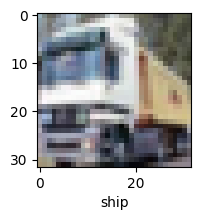

In [36]:
plot_sample(X_test,y_test,1)

In [26]:
y_pred = cnn.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [27]:
y_pred[:5]

array([[4.5182887e-03, 4.3572071e-03, 3.0857762e-03, 9.0129614e-01,
        7.7293786e-05, 4.5290027e-02, 3.6283076e-02, 8.9379901e-06,
        3.6898712e-03, 1.3933883e-03],
       [7.8140502e-04, 2.5326677e-02, 1.6475376e-07, 8.9493696e-08,
        5.8599978e-09, 3.6896119e-10, 6.3150063e-09, 3.1781987e-11,
        9.7388601e-01, 5.6870467e-06],
       [7.6173887e-02, 7.3833287e-02, 1.0695222e-03, 5.2792896e-03,
        6.8137776e-03, 9.2669082e-04, 2.1162942e-04, 1.1304563e-03,
        7.5085092e-01, 8.3710529e-02],
       [2.6864141e-01, 1.1194819e-02, 1.6728533e-02, 3.8992891e-03,
        3.6091305e-04, 4.4235319e-05, 2.4262038e-03, 3.0909705e-06,
        6.9315600e-01, 3.5455450e-03],
       [3.0963118e-05, 1.7025037e-04, 4.2956742e-03, 1.2078054e-02,
        7.5195801e-01, 2.7666087e-04, 2.3106119e-01, 1.0800162e-06,
        1.2759035e-04, 6.3069706e-07]], dtype=float32)

In [28]:
y_classes = [np.argmax(i) for i in y_pred]
y_classes[:5]

[np.int64(3), np.int64(8), np.int64(8), np.int64(8), np.int64(4)]

In [29]:
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

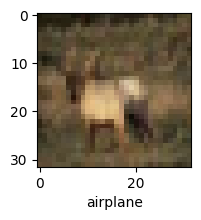

In [33]:
plot_sample(X_test,y_test,3)

In [34]:
classes[y_classes[3]]

'ship'

In [35]:
print("Classification Report: \n", classification_report(y_test, y_classes))

Classification Report: 
               precision    recall  f1-score   support

           0       0.68      0.77      0.72      1000
           1       0.80      0.79      0.79      1000
           2       0.63      0.59      0.61      1000
           3       0.49      0.57      0.53      1000
           4       0.64      0.64      0.64      1000
           5       0.73      0.41      0.52      1000
           6       0.80      0.72      0.76      1000
           7       0.67      0.77      0.72      1000
           8       0.78      0.80      0.79      1000
           9       0.72      0.83      0.77      1000

    accuracy                           0.69     10000
   macro avg       0.70      0.69      0.69     10000
weighted avg       0.70      0.69      0.69     10000



# **Convolution Padding and Stride**


### **Padding**

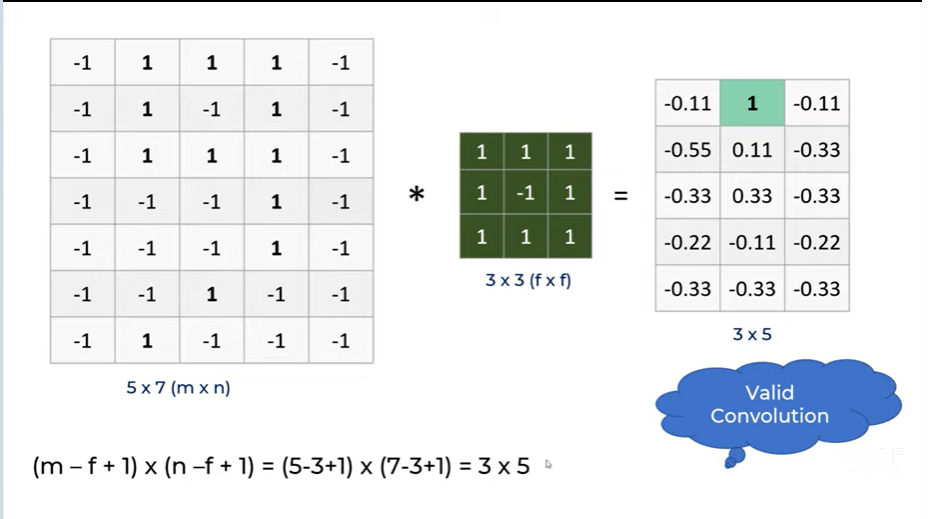

  - But in this corner pixels don't contribute as much in feature detection.
  - To solve this we add padding in image at all side.


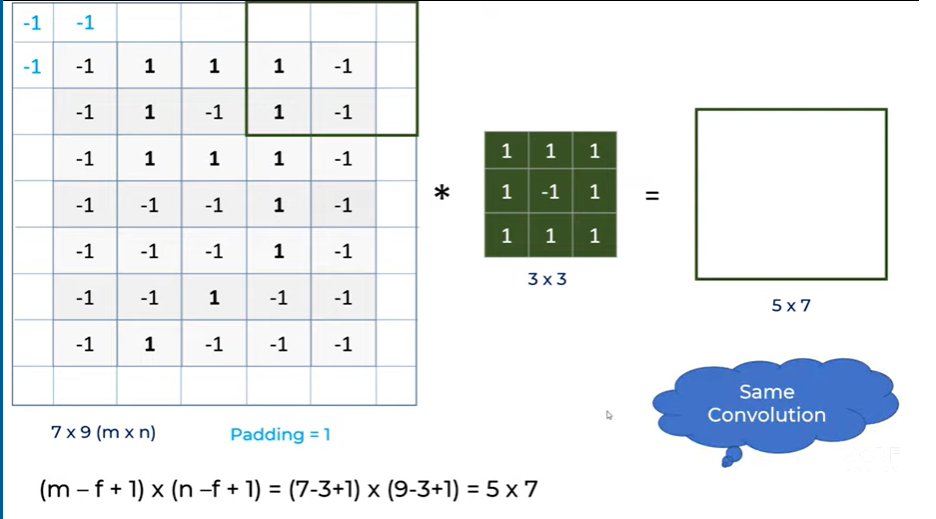

  - Valid Convolution : No padding
  - Same Convolution: Pad such that outpur is same as input
   
   keras.layers.Conv2D(filters,padding='valid/same')

### **Stride**

  - it is steps by which filter is moving it can be (1,1) or (2,2)

  keras.layers.Conv2D(filters,padding='valid/same', strides=(1,1))

In [ ]:
#Handwritten digit Classification using CNN(mnist dataset)